In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from collections import Counter
from sklearn.model_selection import train_test_split

device = "cuda" if torch.cuda.is_available() else "cpu"

torch.manual_seed(42)

print(device)

cuda


In [2]:
import kagglehub

path = kagglehub.dataset_download(
    "lakshmi25npathi/imdb-dataset-of-50k-movie-reviews"
)

print(path)

Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.
/kaggle/input/imdb-dataset-of-50k-movie-reviews


In [3]:
import os

print(os.listdir(path))

['IMDB Dataset.csv']


In [4]:
df = pd.read_csv(path + "/IMDB Dataset.csv")

print(df.head())

                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


In [5]:
df = df.sample(5000, random_state=42)
print(len(df))

5000


In [6]:
df["sentiment"] = df["sentiment"].map({
    "positive": 1,
    "negative": 0
})

In [7]:
def tokenize(text):
    return text.lower().split()

df["tokens"] = df["review"].apply(tokenize)

print(df["tokens"].iloc[0][:20])

['i', 'really', 'liked', 'this', 'summerslam', 'due', 'to', 'the', 'look', 'of', 'the', 'arena,', 'the', 'curtains', 'and', 'just', 'the', 'look', 'overall', 'was']


In [8]:
counter = Counter()

for tokens in df["tokens"]:
    counter.update(tokens)

vocab_size = 10000

most_common = counter.most_common(vocab_size - 2)

vocab = {
    "<pad>": 0,
    "<unk>": 1
}

for idx, (word, _) in enumerate(most_common, start=2):
    vocab[word] = idx

print("Vocabulary size:", len(vocab))

Vocabulary size: 10000


In [9]:
max_len = 200

def encode(tokens):
    encoded = []

    for token in tokens:
        encoded.append(vocab.get(token, 1))

    if len(encoded) < max_len:
        encoded += [0] * (max_len - len(encoded))
    else:
        encoded = encoded[:max_len]

    return encoded

df["encoded"] = df["tokens"].apply(encode)

print(df["review"].iloc[0][:100])

print(df["encoded"].iloc[0][:30])

I really liked this Summerslam due to the look of the arena, the curtains and just the look overall 
[10, 62, 414, 9, 1, 609, 6, 2, 166, 5, 2, 1, 2, 1, 4, 40, 2, 166, 724, 14, 238, 6, 90, 16, 46, 2638, 8865, 9, 93, 26]


In [10]:
X = df["encoded"].tolist()
y = df["sentiment"].tolist()

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [11]:
class IMDBDataset(Dataset):

    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [12]:
train_dataset = IMDBDataset(X_train, y_train)
val_dataset = IMDBDataset(X_val, y_val)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32
)

In [13]:
print("Original review:")
print(df["review"].iloc[0][:200])

print("\nEncoded:")
print(df["encoded"].iloc[0][:30])

Original review:
I really liked this Summerslam due to the look of the arena, the curtains and just the look overall was interesting to me for some reason. Anyways, this could have been one of the best Summerslam's ev

Encoded:
[10, 62, 414, 9, 1, 609, 6, 2, 166, 5, 2, 1, 2, 1, 4, 40, 2, 166, 724, 14, 238, 6, 90, 16, 46, 2638, 8865, 9, 93, 26]


## Task 1 — Implement Scaled Dot-Product Attention from Scratch

Before using PyTorch's built-in attention, build your own.

1.Implement the function scaled_dot_product_attention(Q, K, V, mask=None) returning the attention output and weights, where:

- Q, K, V are tensors of shape (batch, seq_len, d_k)

- mask is an optional boolean tensor where True means "blocked"

2.Use it on a tiny example: 2 sequences of 4 tokens with d_k=8, all values random.

3.Verify your implementation matches nn.functional.scaled_dot_product_attention (or do a manual check that softmax rows sum to 1 and outputs match weights @ V).

4.Print the attention weight matrix for one example. In a markdown cell, comment on its shape and what each row represents.

In [14]:
def scaled_dot_product_attention(Q, K, V, mask=None):

    d_k = Q.size(-1)

    scores = torch.matmul(Q, K.transpose(-2, -1))

    scores = scores / torch.sqrt(torch.tensor(d_k, dtype=torch.float32))

    if mask is not None:
        scores = scores.masked_fill(mask, -1e9)

    attention_weights = torch.softmax(scores, dim=-1)

    output = torch.matmul(attention_weights, V)

    return output, attention_weights

In [15]:
batch_size = 2
seq_len = 4
d_k = 8

Q = torch.rand(batch_size, seq_len, d_k)
K = torch.rand(batch_size, seq_len, d_k)
V = torch.rand(batch_size, seq_len, d_k)

output, weights = scaled_dot_product_attention(Q, K, V)

print("Output shape:", output.shape)
print("Weights shape:", weights.shape)

Output shape: torch.Size([2, 4, 8])
Weights shape: torch.Size([2, 4, 4])


In [17]:
print(weights[0])

print(weights[0].sum(dim=-1))


tensor([[0.2651, 0.2633, 0.2080, 0.2636],
        [0.2764, 0.2331, 0.2542, 0.2363],
        [0.2699, 0.2844, 0.2070, 0.2387],
        [0.2761, 0.2194, 0.2752, 0.2293]])
tensor([1.0000, 1.0000, 1.0000, 1.0000])


The attention weight matrix has shape:

(batch_size, seq_len, seq_len)

Each row represents how much attention one token gives to all other tokens in the sequence.

The values are probabilities because softmax is applied, so every row sums to 1.

## Task 2 — LSTM Classifier

1.Define an LSTMClassifier:

- nn.Embedding(vocab_size, embed_dim=64)

- nn.LSTM(embed_dim, hidden_dim=128, batch_first=True, num_layers=1)

- Take the last hidden state of the LSTM (shape (batch, hidden_dim))

- nn.Dropout(0.3) → nn.Linear(hidden_dim, 2) for binary classification

2.Train for 5 epochs with Adam(lr=1e-3) and CrossEntropyLoss. Time the training with time.time().

3.Plot training and validation loss + accuracy. Report best validation accuracy and total training time.

In [24]:
class LSTMClassifier(nn.Module):

    def __init__(self, vocab_size):

        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            64
        )

        self.lstm = nn.LSTM(
            64,
            128,
            batch_first=True
        )

        self.dropout = nn.Dropout(0.3)

        self.fc = nn.Linear(128, 2)

    def forward(self, x):

        x = self.embedding(x)

        output, (hidden, cell) = self.lstm(x)

        hidden = hidden[-1]

        x = self.dropout(hidden)

        x = self.fc(x)

        return x

In [25]:
lstm_model = LSTMClassifier(
    len(vocab)
).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    lstm_model.parameters(),
    lr=1e-3
)


In [26]:
train_losses = []
val_losses = []

train_accs = []
val_accs = []

start_time = time.time()

for epoch in range(5):

    lstm_model.train()

    total_loss = 0
    correct = 0
    total = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = lstm_model(X_batch)

        loss = criterion(outputs, y_batch)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

        preds = outputs.argmax(dim=1)

        correct += (preds == y_batch).sum().item()

        total += y_batch.size(0)

    train_loss = total_loss / len(train_loader)

    train_acc = correct / total

    train_losses.append(train_loss)

    train_accs.append(train_acc)

    # validation

    lstm_model.eval()

    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = lstm_model(X_batch)

            loss = criterion(outputs, y_batch)

            total_loss += loss.item()

            preds = outputs.argmax(dim=1)

            correct += (preds == y_batch).sum().item()

            total += y_batch.size(0)

    val_loss = total_loss / len(val_loader)

    val_acc = correct / total

    val_losses.append(val_loss)

    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}")

    print(f"Train Loss: {train_loss:.4f}")

    print(f"Validation Loss: {val_loss:.4f}")

    print(f"Train Accuracy: {train_acc:.4f}")

    print(f"Validation Accuracy: {val_acc:.4f}")

total_time = time.time() - start_time

best_lstm_acc = max(val_accs)

lstm_time = total_time

Epoch 1
Train Loss: 0.6999
Validation Loss: 0.6943
Train Accuracy: 0.4840
Validation Accuracy: 0.4920
Epoch 2
Train Loss: 0.6891
Validation Loss: 0.6961
Train Accuracy: 0.5340
Validation Accuracy: 0.4960
Epoch 3
Train Loss: 0.6767
Validation Loss: 0.7461
Train Accuracy: 0.5540
Validation Accuracy: 0.5110
Epoch 4
Train Loss: 0.6497
Validation Loss: 0.7254
Train Accuracy: 0.5880
Validation Accuracy: 0.4940
Epoch 5
Train Loss: 0.6031
Validation Loss: 0.7659
Train Accuracy: 0.6132
Validation Accuracy: 0.5070


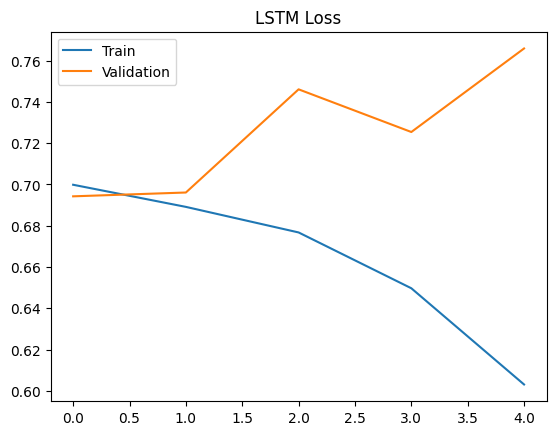

In [27]:
plt.plot(train_losses, label="Train")

plt.plot(val_losses, label="Validation")

plt.legend()

plt.title("LSTM Loss")

plt.show()


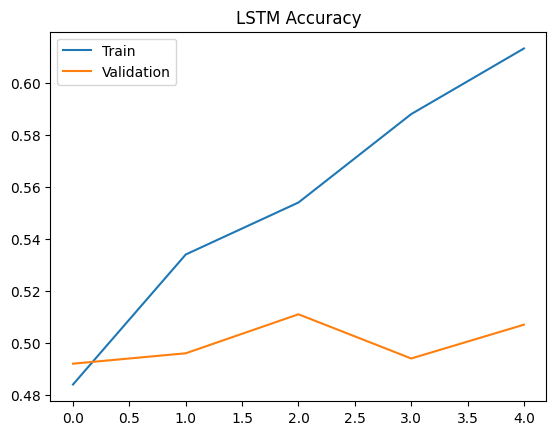

In [28]:
plt.plot(train_accs, label="Train")

plt.plot(val_accs, label="Validation")

plt.legend()

plt.title("LSTM Accuracy")

plt.show()

## Task 3 — Transformer Classifier and Comparison with the LSTM

Build a transformer encoder for the same sentiment task and compare it head-to-head against the LSTM you trained in Task 2.

1.Define a TransformerClassifier:

- nn.Embedding(vocab_size, d_model=64)

- A learned positional encoding nn.Embedding(max_len=200, d_model=64)

- nn.TransformerEncoder with num_layers=2, d_model=64, nhead=4, dim_feedforward=128, batch_first=True, dropout=0.1

- Take the mean over the sequence dimension (or the first token, your choice — note which you picked)

- nn.Dropout(0.3) → nn.Linear(d_model, 2)

2.Train for the same 5 epochs with the same optimiser and loss. Time the training.

3.Plot training and validation loss + accuracy, report best validation accuracy and total training time, then fill in the comparison table below and write a 4–6 sentence comparison of the two models — which converged faster per epoch, which ended at higher accuracy, and whether the transformer's parallelism noticeably affected training time on your hardware.

In [29]:
class TransformerClassifier(nn.Module):

    def __init__(self, vocab_size, max_len=200):

        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            64
        )

        self.pos_embedding = nn.Embedding(
            max_len,
            64
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=64,
            nhead=4,
            dim_feedforward=128,
            dropout=0.1,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=2
        )

        self.dropout = nn.Dropout(0.3)

        self.fc = nn.Linear(64, 2)

    def forward(self, x):

        batch_size, seq_len = x.shape

        positions = torch.arange(
            0,
            seq_len,
            device=device
        ).unsqueeze(0).expand(batch_size, seq_len)

        x = self.embedding(x) + self.pos_embedding(positions)

        x = self.transformer(x)

        # Mean pooling
        x = x.mean(dim=1)

        x = self.dropout(x)

        x = self.fc(x)

        return x

In [30]:
transformer_model = TransformerClassifier(
    len(vocab)
).to(device)

print(transformer_model)

TransformerClassifier(
  (embedding): Embedding(10000, 64)
  (pos_embedding): Embedding(200, 64)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=64, out_features=2, bias=True)
)


In [31]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    transformer_model.parameters(),
    lr=1e-3
)

In [32]:
train_losses, val_losses = [], []
train_accs, val_accs = [], []

start_time = time.time()

for epoch in range(5):

    transformer_model.train()

    total_loss = 0
    correct = 0
    total = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = transformer_model(X_batch)

        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = outputs.argmax(dim=1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

    train_acc = correct / total
    train_loss = total_loss / len(train_loader)

    # validation
    transformer_model.eval()

    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = transformer_model(X_batch)

            loss = criterion(outputs, y_batch)

            val_loss += loss.item()

            preds = outputs.argmax(dim=1)

            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

    val_acc = correct / total
    val_loss = val_loss / len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}")
    print(f"Train loss: {train_loss:.4f} | Val loss: {val_loss:.4f}")
    print(f"Train acc: {train_acc:.4f} | Val acc: {val_acc:.4f}")

total_time = time.time() - start_time

Epoch 1
Train loss: 0.6994 | Val loss: 0.6766
Train acc: 0.5142 | Val acc: 0.5920
Epoch 2
Train loss: 0.6520 | Val loss: 0.5977
Train acc: 0.6110 | Val acc: 0.6820
Epoch 3
Train loss: 0.5088 | Val loss: 0.5806
Train acc: 0.7488 | Val acc: 0.7010
Epoch 4
Train loss: 0.3813 | Val loss: 0.5526
Train acc: 0.8277 | Val acc: 0.7490
Epoch 5
Train loss: 0.2667 | Val loss: 0.6293
Train acc: 0.8890 | Val acc: 0.7540


In [33]:
best_transformer_acc = max(val_accs)

print("Best Val Accuracy:", best_transformer_acc)
print("Training Time:", total_time)


Best Val Accuracy: 0.754
Training Time: 6.926905870437622


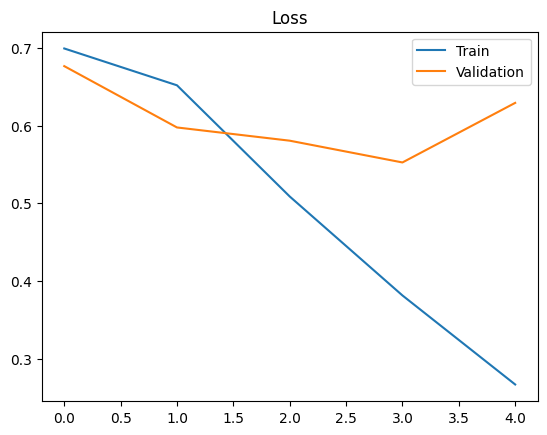

In [34]:
plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Validation")

plt.legend()
plt.title("Loss")
plt.show()

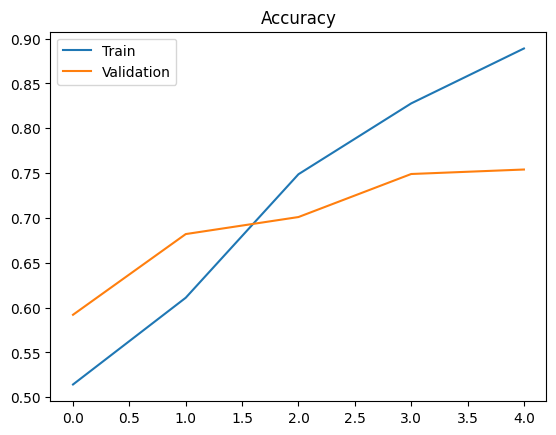

In [35]:
plt.plot(train_accs, label="Train")
plt.plot(val_accs, label="Validation")

plt.legend()
plt.title("Accuracy")
plt.show()

In [36]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

print("Transformer params:", count_parameters(transformer_model))
print("LSTM params:", count_parameters(lstm_model))

Transformer params: 719874
LSTM params: 739586


In [37]:
comparison = pd.DataFrame({
    "Model": ["LSTM", "Transformer"],

    "Best val accuracy": [
        best_lstm_acc,
        best_transformer_acc
    ],

    "Total training time": [
        lstm_time,
        total_time
    ],

    "Parameter count": [
        count_parameters(lstm_model),
        count_parameters(transformer_model)
    ]
})

print(comparison)

         Model  Best val accuracy  Total training time  Parameter count
0         LSTM              0.511             2.474647           739586
1  Transformer              0.754             6.926906           719874


The Transformer model achieved a significantly higher validation accuracy compared to the LSTM model.

The LSTM reached only around 51% validation accuracy, while the Transformer achieved about 75%.

Although the Transformer produced better results, its total training time was longer on CPU hardware.

This is because Transformer models perform many parallel matrix operations which are more efficient on GPUs.

The parameter counts of both models were relatively similar, but the Transformer captured long-range dependencies more effectively using self-attention.